# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [2]:
# Extract zip
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
EXTRACT_DIR = 'heart_ds'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# List CSV files
csv_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(csv_files)

['heart_ds/dataset_heart.csv']


In [3]:
csv_path = csv_files[0]   # first CSV found

df = pd.read_csv(csv_path)

# Inspect
display(df.head())
print(df.shape)
print(df.info())
print(df.columns)

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


(270, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major ves

In [4]:
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

In [6]:
df.columns = df.columns.str.strip()

target = 'heart disease'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

### Basic visual checks

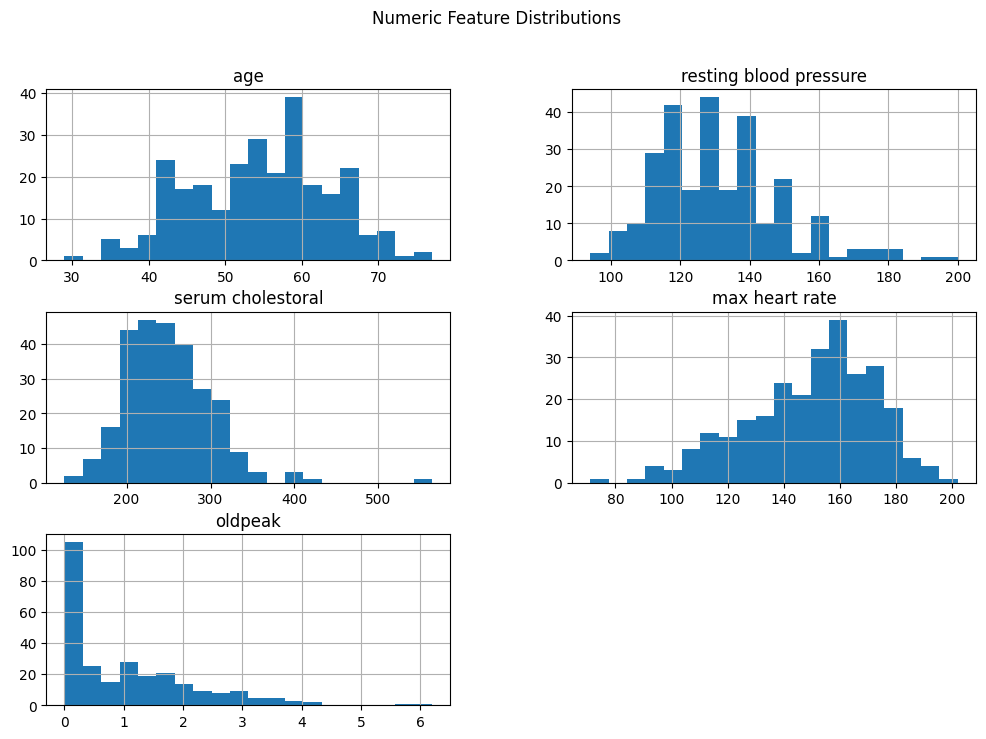

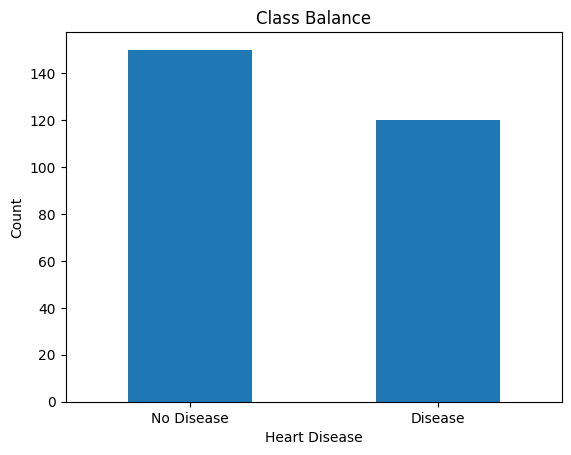

In [7]:
# TODO: pick a few numeric columns and plot histograms

# numeric columns
numeric_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

# Histograms
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.show()


# TODO: plot class balance as a bar chart

df['heart disease'].value_counts().sort_index().plot(kind='bar')

plt.title("Class Balance")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.show()

## Preprocessing pipeline

In [8]:

cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## Helper - evaluation function

In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import matplotlib.pyplot as plt

def eval_and_report(name, model, X_test, y_test):
    # predictions
    y_pred = model.predict(X_test)

    # metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    print(name, metrics)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # ROC curve if predict_proba exists
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC Curve")
        plt.legend()
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


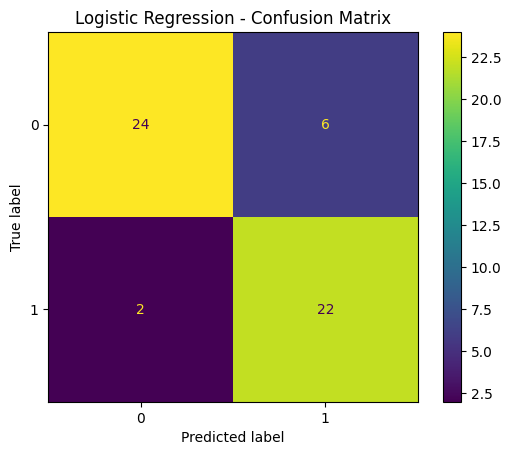

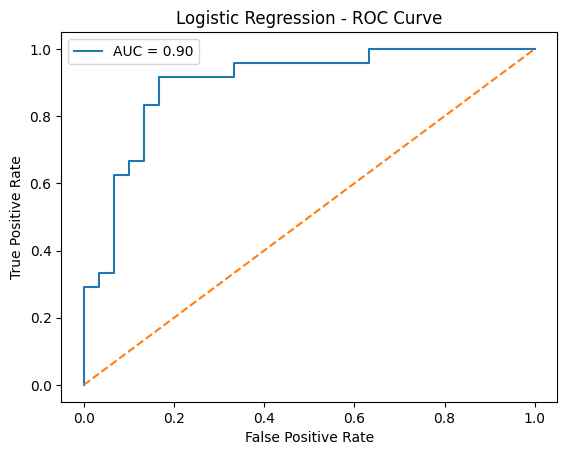

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000))
])

pipe_lr.fit(X_train, y_train)

lr_no_gs_metrics = eval_and_report(
    "Logistic Regression",
    pipe_lr,
    X_test,
    y_test
)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


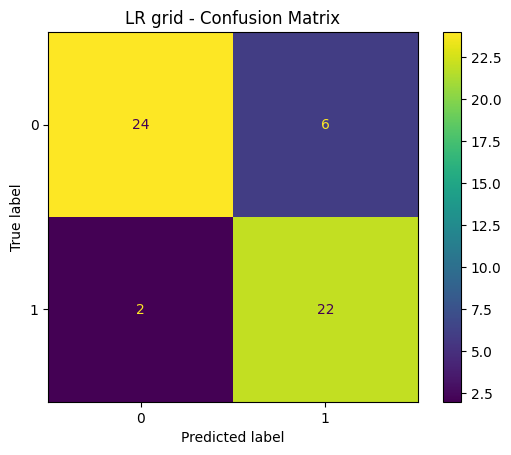

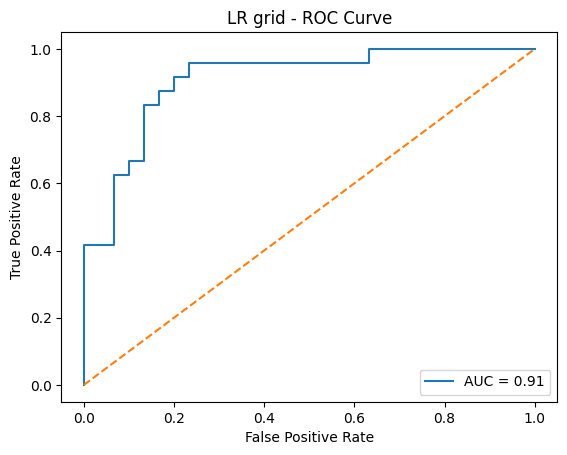

In [11]:
from sklearn.model_selection import GridSearchCV

pipe_lr_cv = Pipeline([
    ('pre', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000))
])

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(
    pipe_lr_cv,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

lr_gs_metrics = eval_and_report(
    'LR grid',
    best_lr,
    X_test,
    y_test
)

## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


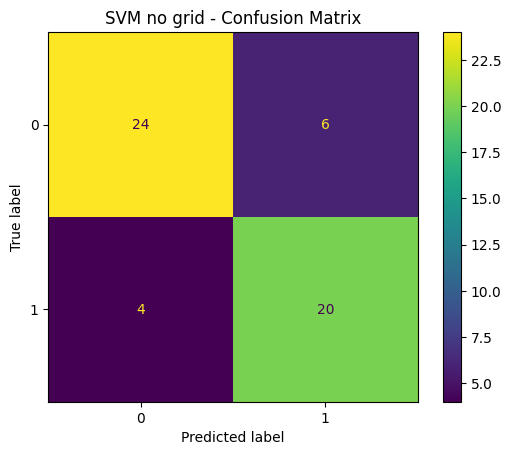

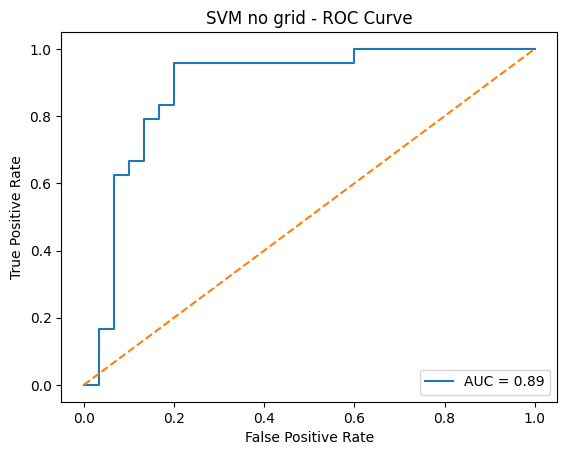

In [12]:
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('pre', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
])

pipe_svm.fit(X_train, y_train)

svm_no_metrics = eval_and_report(
    'SVM no grid',
    pipe_svm,
    X_test,
    y_test
)

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


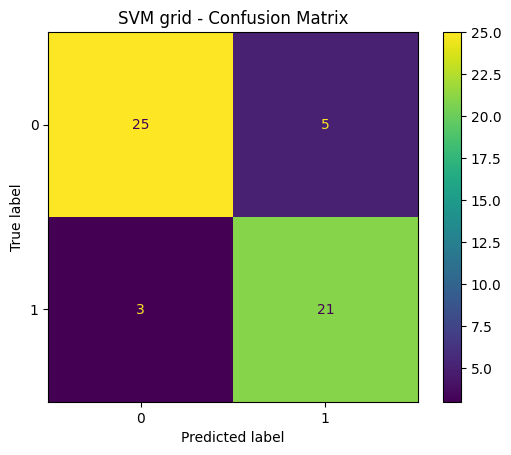

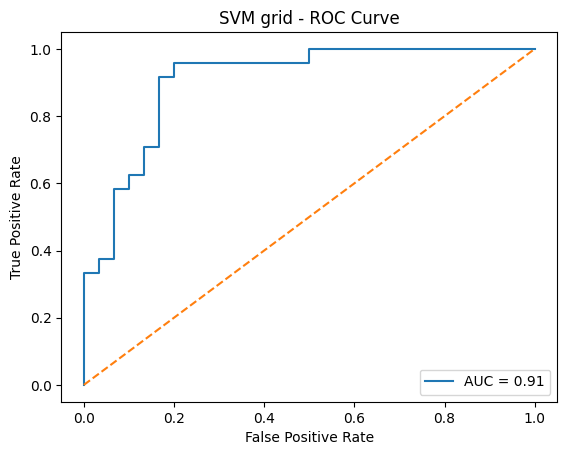

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svm_cv = Pipeline([
    ('pre', pre),
    ('svm', SVC(probability=True))
])

svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    pipe_svm_cv,
    svm_param_grid,
    cv=5,
    scoring='f1'
)

grid_svm.fit(X_train, y_train)

print("Best params:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_

svm_gs_metrics = eval_and_report(
    'SVM grid',
    best_svm,
    X_test,
    y_test
)

## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


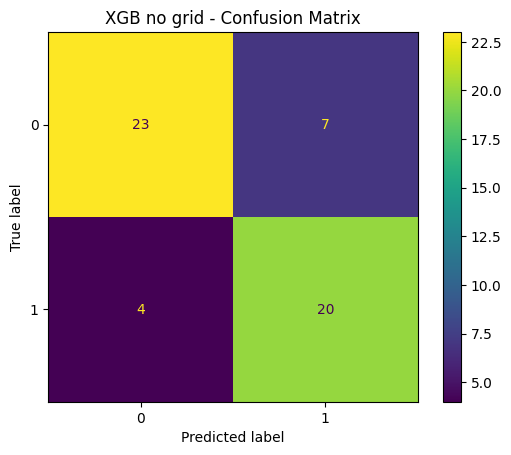

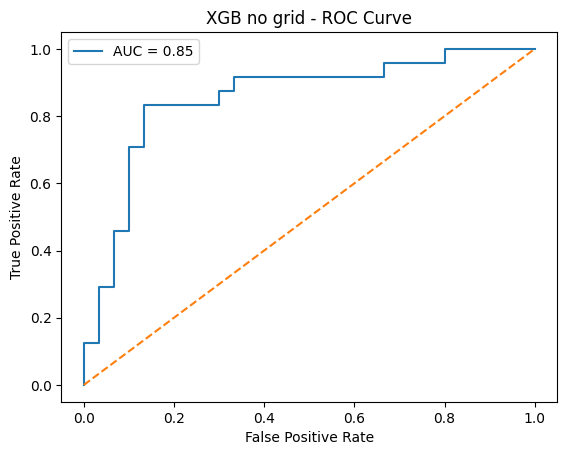

In [14]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss',
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)

xgb_no_metrics = eval_and_report(
    'XGB no grid',
    pipe_xgb,
    X_test,
    y_test
)

## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
XGB grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


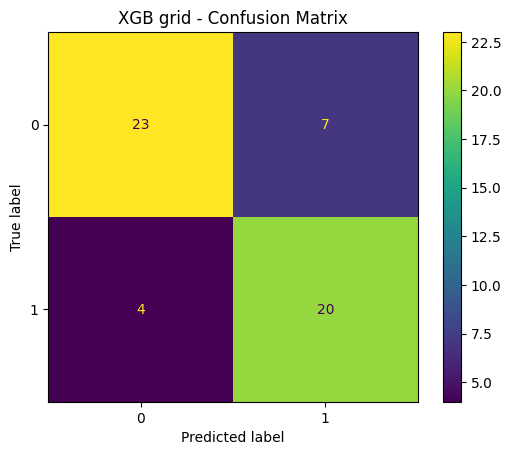

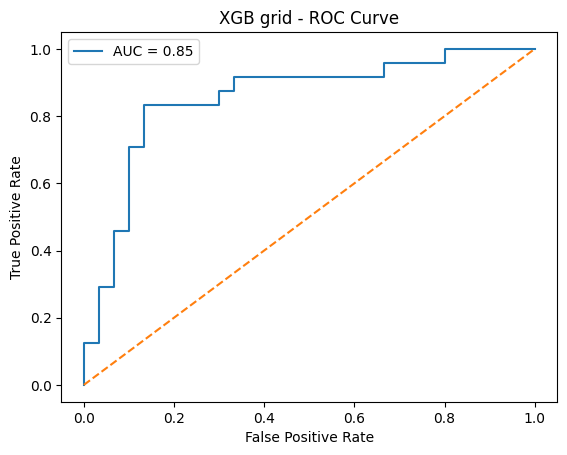

In [15]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

pipe_xgb_cv = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param_grid = {
    'xgb__n_estimators': [100, 300],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    xgb_param_grid,
    cv=5,
    scoring='f1'
)

grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

xgb_gs_metrics = eval_and_report(
    'XGB grid',
    best_xgb,
    X_test,
    y_test
)

## Compare models

In [16]:
summary = {
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics
}

summary_df = pd.DataFrame.from_dict(summary, orient='index')

summary_df

,accuracy,precision,recall,f1
LR no grid,0.851852,0.785714,0.916667,0.846154
LR grid,0.851852,0.785714,0.916667,0.846154
SVM no grid,0.814815,0.769231,0.833333,0.800000
SVM grid,0.851852,0.807692,0.875000,0.840000
XGB no grid,0.796296,0.740741,0.833333,0.784314
XGB grid,0.796296,0.740741,0.833333,0.784314
